In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

dataset = "qqp"
seed = 2026
selected_dp_percent = [i for i in range(1, 101)]
iteration = 500


def plot_data_selection(seed, dataset, train_data, g, iteration=500):
    """Plot 9-subplot data-selection figure for one (dataset, train_data) setting.

    Looks up the following variables from g (caller's globals()):
      - seed{seed}_{dataset}_{train_data}_inv_lam1e_6
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_inv1e_6     (R in ranks)
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_eigen1e_2   (R in ranks)
      - seed{seed}_{dataset}_{train_data}_A_BASE
      - seed{seed}_{dataset}_{train_data}_inv_early_stop
      - seed{seed}_{dataset}_{train_data}_topr_early_stop
      - selected_dp_percent  (shared)
    """
    selected_dp_percent = g["selected_dp_percent"]
    inv             = g[f"seed{seed}_{dataset}_{train_data}_inv_lam1e_6"]
    A_BASE          = g[f"seed{seed}_{dataset}_{train_data}_A_BASE"]
    inv_early_stop  = g[f"seed{seed}_{dataset}_{train_data}_inv_early_stop"]
    topr_early_stop = g[f"seed{seed}_{dataset}_{train_data}_topr_early_stop"]

    ranks = [1, 5, 10, 15, 20, 25, 30]
    eigen_data_1 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_eigen1e_2"], f"rank {r}%") for r in ranks]
    eigen_data_2 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_inv1e_6"],   f"rank {r}%") for r in ranks]
    diff_data    = [(np.array(d1) - np.array(d2), lab)
                    for (d1, lab), (d2, _) in zip(eigen_data_1, eigen_data_2)]

    num_dp = train_data
    ZOOM_PCT = 20
    ZOOM_N = ZOOM_PCT

    fig, axes = plt.subplots(3, 3, figsize=(30, 28))
    axes = axes.flatten()

    inv_color = "red"
    eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

    # ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~ZOOM_PCT% =====
    ax1 = axes[0]
    plot_percent_10 = selected_dp_percent[:ZOOM_N]
    ax1.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax1.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)

    all_data_10_eigen = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_1]
    y_min_10 = min(min(d) for d in all_data_10_eigen)
    y_max_10 = max(max(d) for d in all_data_10_eigen)
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ylim_10_min = y_min_10 - y_margin_10
    ylim_10_max = y_max_10 + y_margin_10

    ax1.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax1.set_ylabel("Accuracy", fontsize=20)
    ax1.set_title(f"Eigen Shapley + Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax1.legend(fontsize=20, loc="best")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax1.set_ylim(ylim_10_min, ylim_10_max)
    ax1.tick_params(axis="both", labelsize=18)

    # ===== Subplot (1,2): Eigen shapley + INV prediction - 1~ZOOM_PCT% =====
    ax2 = axes[1]
    ax2.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax2.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)

    all_data_10_inv = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_2]
    y_min_10_inv = min(min(d) for d in all_data_10_inv)
    y_max_10_inv = max(max(d) for d in all_data_10_inv)
    ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
    ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

    ax2.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax2.set_ylabel("Accuracy", fontsize=20)
    ax2.set_title(f"Eigen Shapley + INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax2.legend(fontsize=20, loc="best")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax2.set_ylim(ylim_10_min, ylim_10_max)
    ax2.tick_params(axis="both", labelsize=18)

    ax1.set_ylim(ylim_10_min, ylim_10_max)

    # ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
    ax3 = axes[2]
    for i, (data, label) in enumerate(diff_data):
        ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="d", markersize=6, label=label, alpha=0.85)

    all_diff_data = [d[0] for d in diff_data]
    y_min_diff = min(min(d) for d in all_diff_data)
    y_max_diff = max(max(d) for d in all_diff_data)
    y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
    ylim_diff_min = y_min_diff - y_margin_diff
    ylim_diff_max = y_max_diff + y_margin_diff

    ax3.axhline(y=0, color="black", linestyle="--", linewidth=1.5, alpha=0.5)
    ax3.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax3.set_ylabel("Accuracy Difference", fontsize=20)
    ax3.set_title(f"Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax3.legend(fontsize=20, loc="best")
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 101)
    ax3.set_ylim(ylim_diff_min, ylim_diff_max)
    ax3.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
    ax4 = axes[3]
    ax4.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=6, label=label, alpha=0.85)

    all_data_100_eigen = [inv] + [d[0] for d in eigen_data_1]
    y_min_100 = min(min(d) for d in all_data_100_eigen)
    y_max_100 = max(max(d) for d in all_data_100_eigen)
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ylim_100_min = y_min_100 - y_margin_100
    ylim_100_max = y_max_100 + y_margin_100

    ax4.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax4.set_ylabel("Accuracy", fontsize=20)
    ax4.set_title(f"Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax4.legend(fontsize=20, loc="best")
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, 101)
    ax4.set_ylim(ylim_100_min, ylim_100_max)
    ax4.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
    ax5 = axes[4]
    ax5.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=6, label=label, alpha=0.85)

    all_data_100_inv = [inv] + [d[0] for d in eigen_data_2]
    y_min_100_inv = min(min(d) for d in all_data_100_inv)
    y_max_100_inv = max(max(d) for d in all_data_100_inv)
    ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
    ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

    ax5.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax5.set_ylabel("Accuracy", fontsize=20)
    ax5.set_title(f"Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax5.legend(fontsize=20, loc="best")
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, 101)
    ax5.set_ylim(ylim_100_min, ylim_100_max)
    ax5.tick_params(axis="both", labelsize=18)

    ax4.set_ylim(ylim_100_min, ylim_100_max)

    # ===== Subplot (2,3): Early Stop Ratio =====
    ax6 = axes[5]
    method_names = ["INV"] + [f"rank {r}%" for r in ranks]
    method_values = [inv_early_stop[0]] + list(topr_early_stop)
    bar_colors = [inv_color] + list(eigen_colors)
    x_pos = np.arange(len(method_names))
    bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor="black", linewidth=1.2)
    for bar, value in zip(bars, method_values):
        ax6.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                 f"{value:.2f}", ha="center", va="bottom", fontsize=20, fontweight="bold")
    ax6.set_xlabel("Method", fontsize=20)
    ax6.set_ylabel("Early Stop Ratio (%)", fontsize=20)
    ax6.set_title(f"Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(method_names, fontsize=20)
    ax6.grid(True, alpha=0.3, axis="y")
    ax6.tick_params(axis="y", labelsize=18)

    # ===== Subplot (3,1): ER for Eigen Pred - 1~ZOOM_PCT% =====
    ax7 = axes[6]
    inv_zoom_arr = np.array(inv[:ZOOM_N])

    er_data_eigen = []
    for i, (data, label) in enumerate(eigen_data_1):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_eigen.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_eigen):
        ax7.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)
    ax7.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax7.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax7.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax7.set_title(f"ER: Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax7.legend(fontsize=20, loc="best")
    ax7.grid(True, alpha=0.3)
    ax7.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax7.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,2): ER for INV Pred - 1~ZOOM_PCT% =====
    ax8 = axes[7]
    er_data_inv = []
    for i, (data, label) in enumerate(eigen_data_2):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_inv.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_inv):
        ax8.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)
    ax8.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax8.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax8.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax8.set_title(f"ER: INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax8.legend(fontsize=20, loc="best")
    ax8.grid(True, alpha=0.3)
    ax8.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax8.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,3): Turn off =====
    axes[8].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:

# ===== Configuration =====
num_dp = 1000
# =========================

seed2026_qqp_1000_A_BASE = 

seed2026_qqp_1000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_qqp_1000_r1_eigen1e_2_inv1e_6  = 
seed2026_qqp_1000_r5_eigen1e_2_inv1e_6  = 
seed2026_qqp_1000_r10_eigen1e_2_inv1e_6 = 
seed2026_qqp_1000_r15_eigen1e_2_inv1e_6 = 
seed2026_qqp_1000_r20_eigen1e_2_inv1e_6 = 
seed2026_qqp_1000_r25_eigen1e_2_inv1e_6 = 
seed2026_qqp_1000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_qqp_1000_r1_eigen1e_2_eigen1e_2  = 
seed2026_qqp_1000_r5_eigen1e_2_eigen1e_2  = 
seed2026_qqp_1000_r10_eigen1e_2_eigen1e_2 = 
seed2026_qqp_1000_r15_eigen1e_2_eigen1e_2 = 
seed2026_qqp_1000_r20_eigen1e_2_eigen1e_2 = 
seed2026_qqp_1000_r25_eigen1e_2_eigen1e_2 = 
seed2026_qqp_1000_r30_eigen1e_2_eigen1e_2 = 

seed2026_qqp_1000_inv_early_stop  = []
seed2026_qqp_1000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
# =========================

seed2026_qqp_2000_A_BASE = 

seed2026_qqp_2000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_qqp_2000_r1_eigen1e_2_inv1e_6  = 
seed2026_qqp_2000_r5_eigen1e_2_inv1e_6  = 
seed2026_qqp_2000_r10_eigen1e_2_inv1e_6 = 
seed2026_qqp_2000_r15_eigen1e_2_inv1e_6 = 
seed2026_qqp_2000_r20_eigen1e_2_inv1e_6 = 
seed2026_qqp_2000_r25_eigen1e_2_inv1e_6 = 
seed2026_qqp_2000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_qqp_2000_r1_eigen1e_2_eigen1e_2  = 
seed2026_qqp_2000_r5_eigen1e_2_eigen1e_2  = 
seed2026_qqp_2000_r10_eigen1e_2_eigen1e_2 = 
seed2026_qqp_2000_r15_eigen1e_2_eigen1e_2 = 
seed2026_qqp_2000_r20_eigen1e_2_eigen1e_2 = 
seed2026_qqp_2000_r25_eigen1e_2_eigen1e_2 = 
seed2026_qqp_2000_r30_eigen1e_2_eigen1e_2 = 

seed2026_qqp_2000_inv_early_stop  = []
seed2026_qqp_2000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


/tmp/ipykernel_1029142/2277458953.py:191: RuntimeWarning: divide by zero encountered in divide
  ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
/tmp/ipykernel_1029142/2277458953.py:191: RuntimeWarning: invalid value encountered in divide
  ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
/home/donghwan/.conda/envs/freeshap/lib/python3.10/site-packages/numpy/core/_methods.py:233: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_1029142/2277458953.py:210: RuntimeWarning: invalid value encountered in divide
  ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
/tmp/ipykernel_1029142/2277458953.py:210: RuntimeWarning: divide by zero encountered in divide
  ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)


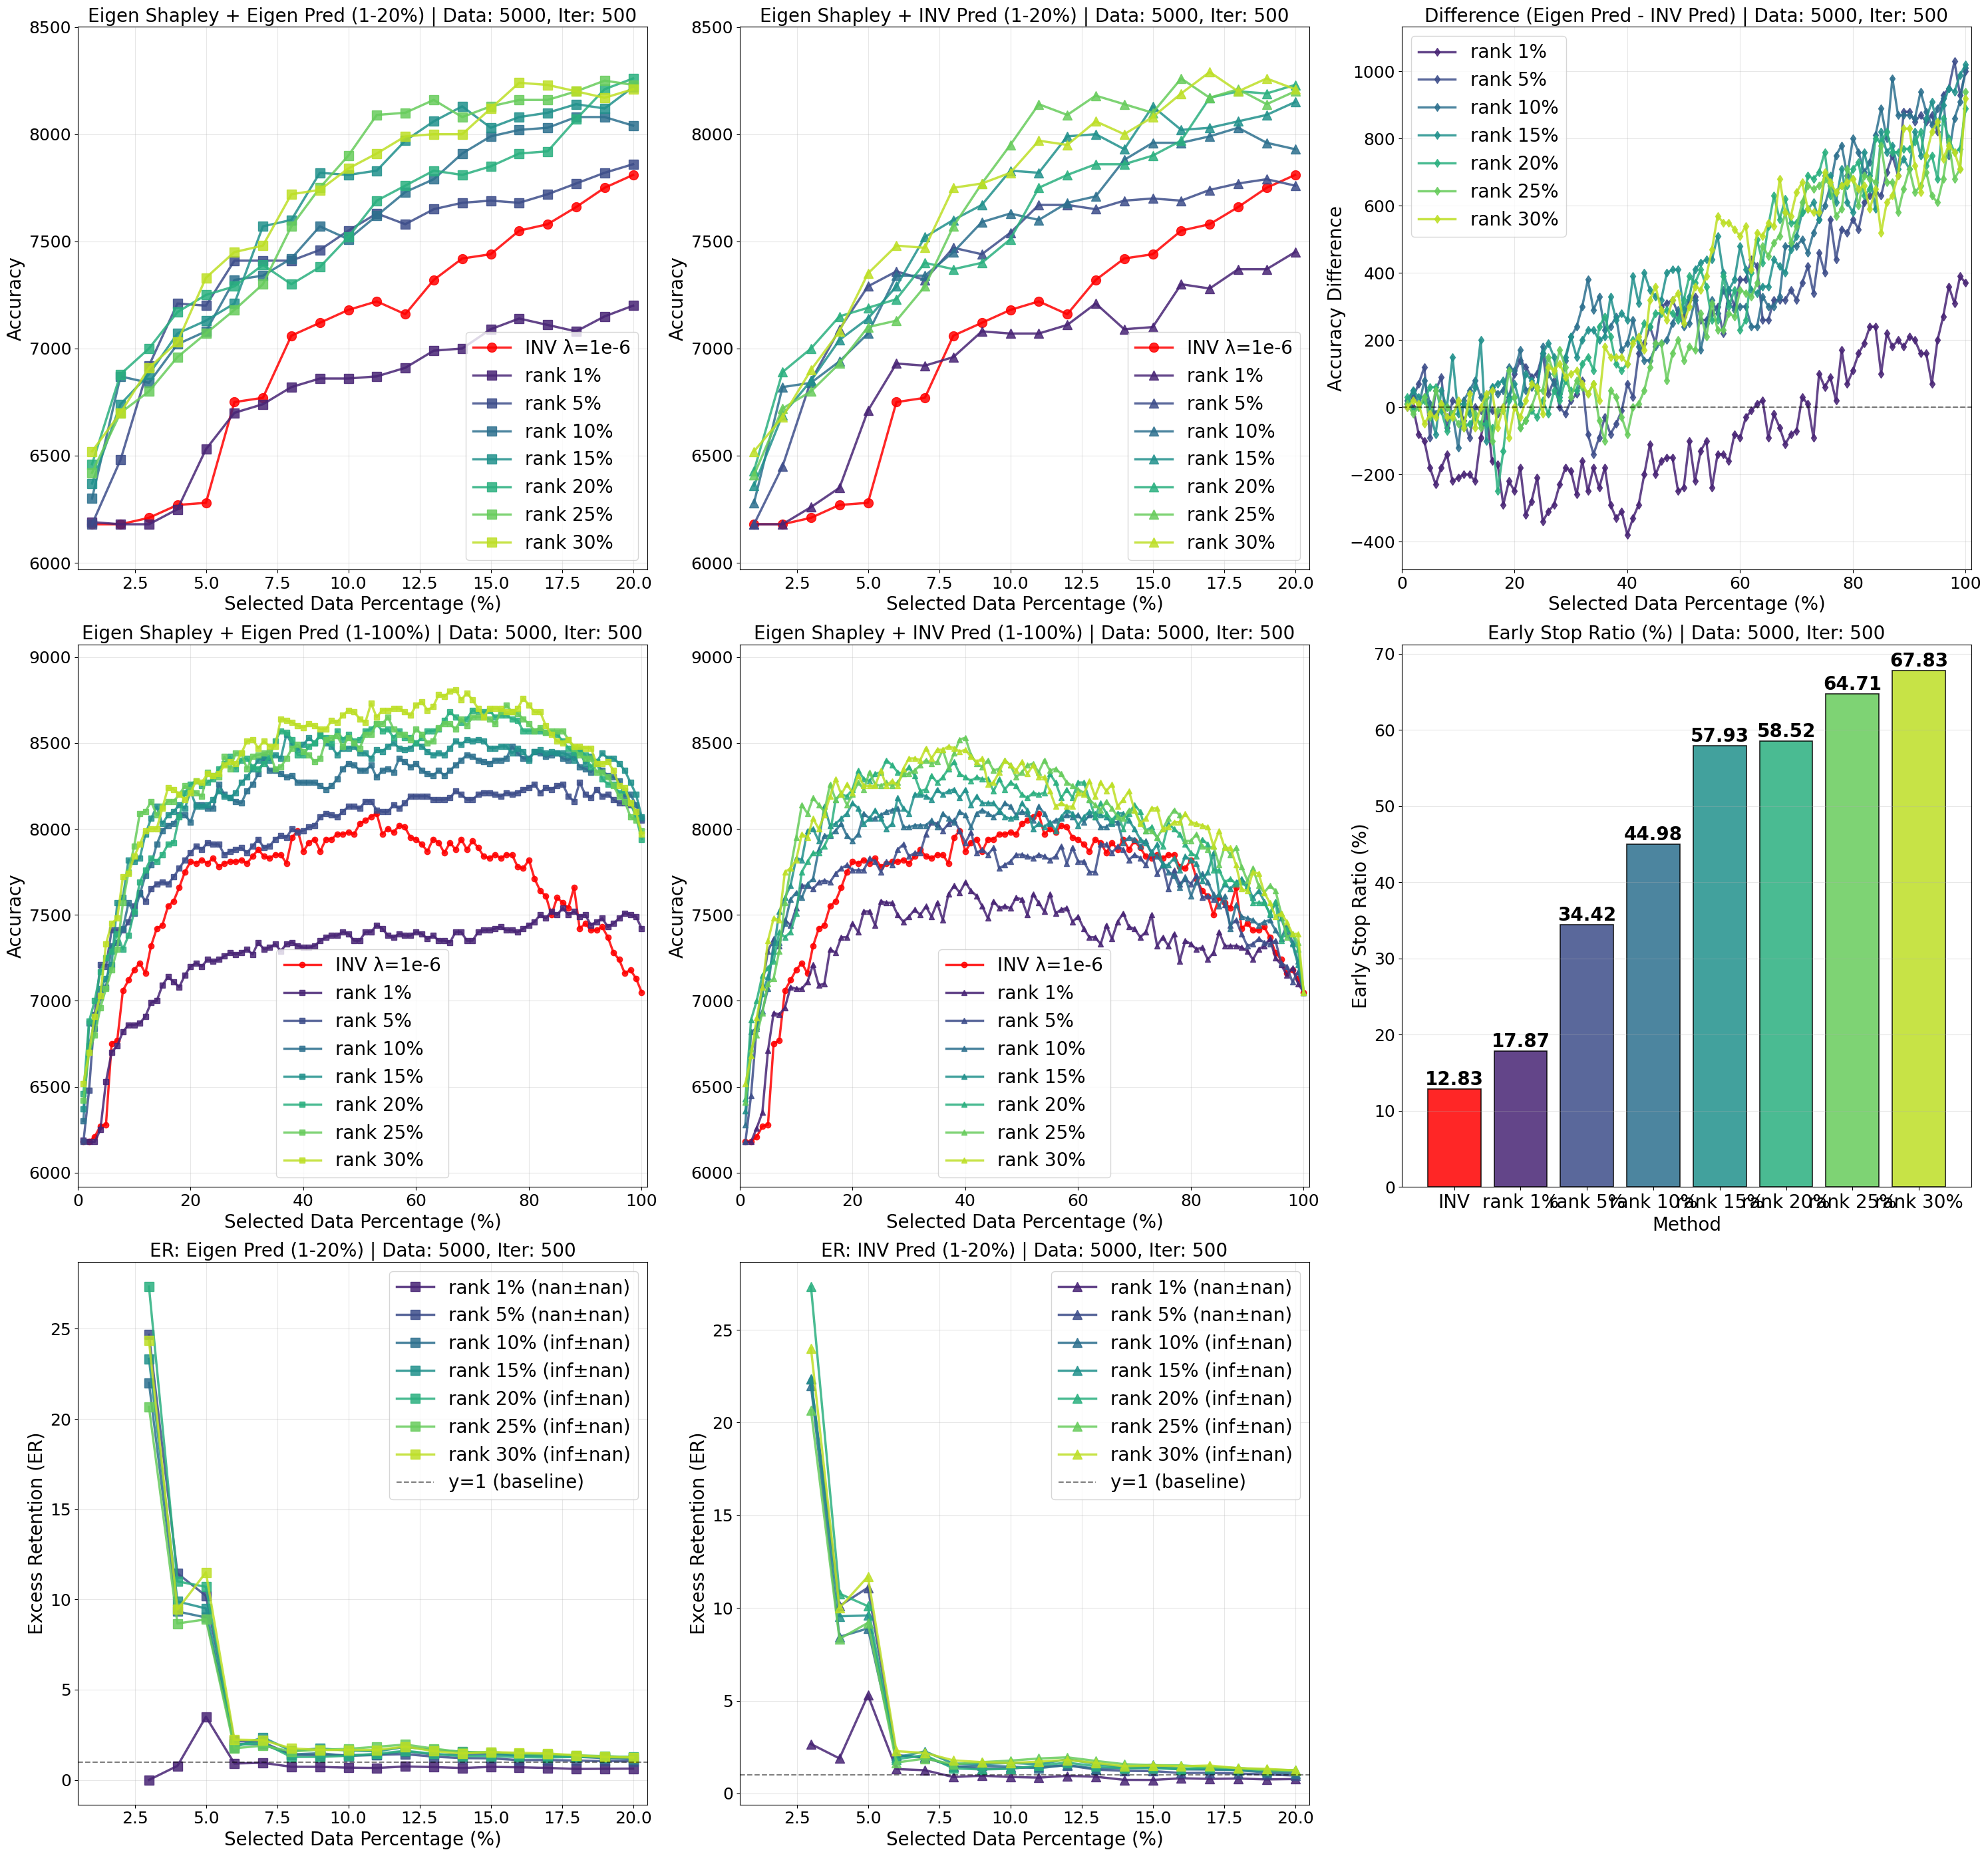

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
# =========================

seed2026_qqp_5000_A_BASE = 6180

seed2026_qqp_5000_inv_lam1e_6           = [6180, 6180, 6210, 6270, 6280, 6750, 6770, 7060, 7120, 7180, 7220, 7160, 7320, 7420, 7440, 7550, 7580, 7660, 7750, 7810, 7800, 7820, 7800, 7830, 7780, 7800, 7810, 7810, 7820, 7800, 7840, 7880, 7840, 7830, 7850, 7850, 7800, 7950, 7990, 7870, 7920, 7940, 7870, 7940, 7940, 7970, 7970, 7980, 7970, 8030, 8050, 8070, 8090, 7970, 8000, 7980, 8020, 8010, 7950, 7940, 7910, 7870, 7940, 7920, 7860, 7920, 7880, 7940, 7880, 7930, 7890, 7840, 7830, 7850, 7830, 7850, 7850, 7780, 7770, 7820, 7710, 7640, 7610, 7500, 7600, 7570, 7540, 7660, 7420, 7450, 7410, 7410, 7430, 7370, 7280, 7240, 7160, 7180, 7130, 7050]
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_qqp_5000_r1_eigen1e_2_inv1e_6  = [6180, 6180, 6260, 6350, 6710, 6930, 6920, 6960, 7080, 7070, 7070, 7110, 7210, 7090, 7100, 7300, 7280, 7370, 7370, 7450, 7400, 7520, 7520, 7440, 7580, 7570, 7570, 7500, 7460, 7490, 7530, 7500, 7550, 7490, 7570, 7470, 7620, 7670, 7630, 7690, 7640, 7610, 7550, 7480, 7580, 7540, 7550, 7540, 7600, 7590, 7500, 7620, 7570, 7520, 7620, 7510, 7530, 7540, 7460, 7490, 7420, 7370, 7370, 7330, 7440, 7360, 7460, 7510, 7430, 7420, 7370, 7400, 7500, 7320, 7370, 7320, 7390, 7230, 7350, 7330, 7300, 7310, 7240, 7280, 7400, 7320, 7320, 7320, 7310, 7290, 7240, 7300, 7320, 7360, 7250, 7210, 7150, 7190, 7100, 7050]
seed2026_qqp_5000_r5_eigen1e_2_inv1e_6  = [6180, 6450, 6850, 7090, 7290, 7360, 7320, 7470, 7440, 7540, 7670, 7670, 7650, 7690, 7700, 7690, 7740, 7770, 7790, 7760, 7760, 7760, 7830, 7810, 7750, 7810, 7790, 7880, 7910, 7840, 7860, 7860, 7970, 8040, 8030, 7990, 8030, 8050, 7990, 7920, 7980, 7860, 7880, 7850, 7890, 7770, 7790, 7810, 7850, 7850, 7840, 7830, 7850, 7840, 7820, 7840, 7900, 7800, 7890, 7810, 7810, 7750, 7750, 7910, 7910, 7860, 7900, 7880, 7820, 7850, 7830, 7790, 7870, 7740, 7790, 7650, 7760, 7680, 7710, 7680, 7730, 7600, 7610, 7590, 7620, 7560, 7440, 7470, 7390, 7320, 7330, 7360, 7340, 7330, 7350, 7220, 7200, 7110, 7170, 7050]
seed2026_qqp_5000_r10_eigen1e_2_inv1e_6 = [6280, 6820, 6840, 6940, 7070, 7340, 7340, 7450, 7590, 7630, 7600, 7680, 7710, 7880, 7960, 7960, 7990, 8030, 7960, 7930, 7970, 8090, 8060, 8060, 8080, 8100, 8110, 8120, 8010, 8010, 8020, 8020, 8020, 8050, 8010, 8090, 8060, 8040, 8100, 8080, 8010, 8090, 8110, 8090, 8070, 8100, 8150, 8130, 8080, 8100, 8090, 8050, 8130, 8090, 8030, 8050, 8060, 8080, 8070, 8080, 8040, 8080, 8070, 8010, 8010, 8040, 8040, 7920, 7950, 7940, 7900, 7930, 7860, 7840, 7800, 7750, 7730, 7660, 7720, 7610, 7690, 7740, 7690, 7620, 7550, 7610, 7420, 7560, 7490, 7480, 7470, 7440, 7460, 7470, 7410, 7360, 7440, 7340, 7230, 7050]
seed2026_qqp_5000_r15_eigen1e_2_inv1e_6 = [6360, 6690, 6850, 7040, 7140, 7290, 7520, 7600, 7670, 7830, 7820, 7990, 8000, 7930, 8130, 8020, 8030, 8060, 8090, 8150, 8120, 8030, 8060, 8110, 8060, 8000, 8030, 8180, 8120, 8090, 8200, 8200, 8190, 8170, 8230, 8200, 8220, 8230, 8180, 8230, 8140, 8190, 8150, 8150, 8150, 8110, 8070, 8060, 8070, 8150, 8110, 8000, 8030, 8010, 8040, 7990, 8070, 8110, 8090, 8020, 8070, 8100, 8090, 8080, 8070, 8030, 8090, 8090, 8050, 8000, 7940, 7920, 7860, 7910, 7790, 7790, 7830, 7760, 7840, 7820, 7800, 7700, 7750, 7860, 7620, 7680, 7650, 7690, 7710, 7670, 7600, 7640, 7580, 7500, 7570, 7480, 7390, 7330, 7210, 7050]
seed2026_qqp_5000_r20_eigen1e_2_inv1e_6 = [6430, 6890, 7000, 7150, 7190, 7230, 7400, 7370, 7400, 7510, 7750, 7810, 7860, 7860, 7900, 7970, 8170, 8200, 8190, 8230, 8340, 8290, 8280, 8320, 8330, 8400, 8370, 8330, 8320, 8360, 8310, 8220, 8230, 8310, 8270, 8300, 8350, 8390, 8320, 8300, 8280, 8300, 8290, 8290, 8220, 8290, 8230, 8270, 8250, 8200, 8180, 8210, 8200, 8210, 8320, 8270, 8180, 8230, 8180, 8270, 8270, 8170, 8070, 8150, 8090, 8050, 8090, 8000, 8090, 8140, 8100, 7990, 8010, 7950, 7900, 8030, 8000, 7970, 7910, 7860, 7840, 7940, 7910, 7760, 7760, 7690, 7710, 7680, 7690, 7660, 7570, 7570, 7570, 7510, 7580, 7350, 7420, 7390, 7300, 7050]
seed2026_qqp_5000_r25_eigen1e_2_inv1e_6 = [6410, 6720, 6800, 6930, 7100, 7130, 7290, 7570, 7770, 7950, 8140, 8090, 8180, 8140, 8100, 8260, 8170, 8210, 8140, 8200, 8270, 8230, 8330, 8260, 8250, 8270, 8250, 8270, 8320, 8320, 8340, 8370, 8400, 8380, 8390, 8460, 8360, 8440, 8520, 8530, 8430, 8380, 8360, 8400, 8340, 8350, 8400, 8370, 8300, 8330, 8370, 8380, 8330, 8400, 8340, 8350, 8320, 8270, 8250, 8230, 8210, 8170, 8140, 8110, 8160, 8120, 8070, 8060, 8110, 8110, 8040, 7990, 7990, 7950, 8000, 8060, 8110, 8080, 7930, 7930, 7970, 7900, 7880, 7900, 7790, 7900, 7850, 7890, 7780, 7700, 7770, 7670, 7630, 7670, 7640, 7510, 7370, 7390, 7340, 7050]
seed2026_qqp_5000_r30_eigen1e_2_inv1e_6 = [6520, 6680, 6900, 7080, 7350, 7480, 7470, 7750, 7770, 7820, 7970, 7950, 8060, 8000, 8080, 8190, 8290, 8200, 8260, 8210, 8310, 8250, 8250, 8250, 8340, 8250, 8280, 8250, 8350, 8410, 8410, 8400, 8470, 8410, 8460, 8460, 8480, 8470, 8450, 8460, 8420, 8390, 8410, 8260, 8270, 8330, 8400, 8370, 8340, 8390, 8320, 8370, 8300, 8300, 8220, 8130, 8150, 8130, 8130, 8210, 8200, 8280, 8190, 8270, 8220, 8260, 8130, 8170, 8220, 8110, 8030, 8060, 8120, 8120, 8000, 8010, 8040, 8040, 8090, 8040, 8030, 8020, 8010, 7900, 7990, 7890, 7890, 7790, 7650, 7640, 7750, 7740, 7630, 7570, 7490, 7510, 7460, 7390, 7390, 7050]

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_qqp_5000_r1_eigen1e_2_eigen1e_2  = [6190, 6180, 6180, 6250, 6530, 6700, 6740, 6820, 6860, 6860, 6870, 6910, 6990, 7000, 7090, 7140, 7110, 7080, 7150, 7200, 7220, 7200, 7240, 7230, 7240, 7260, 7280, 7270, 7280, 7300, 7270, 7340, 7300, 7310, 7330, 7290, 7330, 7340, 7320, 7310, 7310, 7320, 7350, 7370, 7380, 7380, 7400, 7390, 7350, 7350, 7400, 7400, 7440, 7420, 7380, 7370, 7390, 7380, 7380, 7400, 7390, 7360, 7380, 7350, 7350, 7340, 7400, 7400, 7350, 7350, 7400, 7410, 7410, 7420, 7430, 7410, 7410, 7400, 7420, 7440, 7460, 7500, 7480, 7520, 7500, 7540, 7500, 7520, 7490, 7500, 7440, 7460, 7480, 7430, 7450, 7480, 7510, 7500, 7490, 7420]
seed2026_qqp_5000_r5_eigen1e_2_eigen1e_2  = [6180, 6480, 6920, 7210, 7200, 7410, 7410, 7410, 7460, 7550, 7630, 7580, 7650, 7680, 7690, 7680, 7720, 7770, 7820, 7860, 7900, 7880, 7920, 7910, 7910, 7850, 7870, 7880, 7890, 7860, 7900, 7940, 7890, 7900, 7940, 7960, 7950, 8000, 7980, 7990, 8010, 8020, 8070, 8090, 8080, 8070, 8100, 8130, 8130, 8120, 8160, 8160, 8110, 8100, 8100, 8140, 8120, 8150, 8190, 8190, 8190, 8190, 8170, 8170, 8170, 8180, 8220, 8200, 8170, 8170, 8200, 8210, 8210, 8200, 8190, 8210, 8200, 8210, 8230, 8240, 8260, 8210, 8240, 8230, 8250, 8260, 8190, 8160, 8270, 8200, 8180, 8230, 8190, 8200, 8170, 8150, 8150, 8140, 8100, 8050]
seed2026_qqp_5000_r10_eigen1e_2_eigen1e_2 = [6300, 6870, 6840, 7020, 7080, 7320, 7340, 7420, 7570, 7510, 7620, 7730, 7790, 7910, 7990, 8020, 8030, 8080, 8080, 8040, 8140, 8140, 8120, 8120, 8260, 8200, 8180, 8160, 8150, 8220, 8260, 8320, 8400, 8340, 8340, 8320, 8300, 8310, 8270, 8270, 8270, 8270, 8250, 8230, 8250, 8290, 8350, 8380, 8370, 8340, 8340, 8370, 8300, 8340, 8350, 8330, 8410, 8390, 8360, 8380, 8340, 8320, 8310, 8340, 8310, 8340, 8370, 8400, 8430, 8420, 8400, 8390, 8380, 8400, 8400, 8410, 8480, 8440, 8410, 8410, 8450, 8440, 8420, 8430, 8440, 8410, 8400, 8430, 8360, 8350, 8330, 8380, 8340, 8310, 8300, 8280, 8190, 8200, 8140, 8060]
seed2026_qqp_5000_r15_eigen1e_2_eigen1e_2 = [6370, 6740, 6880, 7070, 7130, 7210, 7570, 7600, 7820, 7810, 7830, 7970, 8060, 8130, 8030, 8080, 8100, 8140, 8120, 8220, 8130, 8130, 8140, 8170, 8220, 8190, 8180, 8210, 8270, 8300, 8350, 8400, 8420, 8400, 8430, 8410, 8550, 8490, 8460, 8490, 8530, 8500, 8550, 8500, 8480, 8430, 8470, 8470, 8480, 8440, 8440, 8410, 8460, 8450, 8480, 8500, 8470, 8460, 8470, 8500, 8480, 8450, 8430, 8440, 8430, 8470, 8510, 8490, 8520, 8510, 8520, 8510, 8470, 8470, 8480, 8480, 8440, 8470, 8450, 8400, 8450, 8460, 8440, 8450, 8440, 8440, 8430, 8400, 8450, 8380, 8420, 8390, 8440, 8410, 8410, 8380, 8340, 8270, 8200, 8070]
seed2026_qqp_5000_r20_eigen1e_2_eigen1e_2 = [6460, 6880, 7000, 7170, 7250, 7290, 7390, 7300, 7380, 7520, 7690, 7760, 7830, 7810, 7850, 7910, 7920, 8070, 8210, 8260, 8280, 8250, 8270, 8290, 8350, 8380, 8420, 8350, 8400, 8410, 8360, 8350, 8380, 8420, 8510, 8570, 8560, 8520, 8430, 8430, 8480, 8500, 8540, 8530, 8500, 8570, 8520, 8550, 8510, 8520, 8570, 8580, 8610, 8570, 8580, 8530, 8570, 8530, 8530, 8500, 8530, 8570, 8570, 8580, 8630, 8680, 8650, 8620, 8640, 8690, 8680, 8680, 8690, 8650, 8660, 8660, 8640, 8630, 8570, 8570, 8570, 8570, 8560, 8560, 8550, 8510, 8470, 8440, 8460, 8430, 8360, 8390, 8290, 8260, 8260, 8210, 8220, 8150, 8070, 7940]
seed2026_qqp_5000_r25_eigen1e_2_eigen1e_2 = [6420, 6700, 6800, 6960, 7070, 7180, 7300, 7570, 7750, 7900, 8090, 8100, 8160, 8080, 8130, 8160, 8160, 8200, 8250, 8230, 8210, 8190, 8330, 8310, 8300, 8420, 8350, 8440, 8440, 8350, 8420, 8430, 8440, 8450, 8350, 8360, 8410, 8470, 8490, 8450, 8430, 8390, 8410, 8520, 8530, 8540, 8480, 8530, 8500, 8470, 8550, 8550, 8610, 8610, 8650, 8580, 8550, 8550, 8520, 8580, 8550, 8500, 8510, 8590, 8610, 8610, 8580, 8640, 8600, 8650, 8650, 8650, 8640, 8610, 8680, 8720, 8680, 8670, 8640, 8610, 8570, 8590, 8560, 8570, 8570, 8570, 8520, 8470, 8430, 8410, 8410, 8330, 8330, 8300, 8250, 8190, 8160, 8070, 8050, 7990]
seed2026_qqp_5000_r30_eigen1e_2_eigen1e_2 = [6520, 6700, 6910, 7030, 7330, 7450, 7480, 7720, 7740, 7840, 7910, 7990, 8000, 8000, 8120, 8240, 8230, 8200, 8170, 8210, 8280, 8270, 8320, 8310, 8320, 8370, 8390, 8380, 8440, 8510, 8520, 8470, 8510, 8480, 8480, 8640, 8630, 8620, 8600, 8590, 8610, 8600, 8580, 8580, 8630, 8620, 8660, 8690, 8680, 8640, 8620, 8730, 8650, 8690, 8690, 8700, 8700, 8680, 8660, 8720, 8740, 8690, 8710, 8780, 8770, 8800, 8810, 8750, 8790, 8750, 8700, 8650, 8700, 8700, 8700, 8680, 8680, 8700, 8760, 8720, 8680, 8680, 8600, 8550, 8510, 8500, 8520, 8480, 8480, 8470, 8470, 8380, 8380, 8390, 8340, 8250, 8240, 8150, 8100, 7970]

seed2026_qqp_5000_inv_early_stop  = [12.83]
seed2026_qqp_5000_topr_early_stop = [17.87, 34.42, 44.98, 57.93, 58.52, 64.71, 67.83]

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 10000
# =========================

seed2026_qqp_10000_A_BASE = 

seed2026_qqp_10000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_qqp_10000_r1_eigen1e_2_inv1e_6  = 
seed2026_qqp_10000_r5_eigen1e_2_inv1e_6  = 
seed2026_qqp_10000_r10_eigen1e_2_inv1e_6 = 
seed2026_qqp_10000_r15_eigen1e_2_inv1e_6 = 
seed2026_qqp_10000_r20_eigen1e_2_inv1e_6 = 
seed2026_qqp_10000_r25_eigen1e_2_inv1e_6 = 
seed2026_qqp_10000_r30_eigen1e_2_inv1e_6 = 

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_qqp_10000_r1_eigen1e_2_eigen1e_2  = 
seed2026_qqp_10000_r5_eigen1e_2_eigen1e_2  = 
seed2026_qqp_10000_r10_eigen1e_2_eigen1e_2 = 
seed2026_qqp_10000_r15_eigen1e_2_eigen1e_2 = 
seed2026_qqp_10000_r20_eigen1e_2_eigen1e_2 = 
seed2026_qqp_10000_r25_eigen1e_2_eigen1e_2 = 
seed2026_qqp_10000_r30_eigen1e_2_eigen1e_2 = 

seed2026_qqp_10000_inv_early_stop  = []
seed2026_qqp_10000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)
